# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\elrae\BEE4750\hw2-holly-1`
   Installed JpegTurbo_jll ─────────────── v3.1.3+0
   Installed InlineStrings ─────────────── v1.4.5
   Installed NetworkLayout ─────────────── v0.4.10
   Installed Libmount_jll ──────────────── v2.41.1+0
   Installed OffsetArrays ──────────────── v1.17.0
   Installed Accessors ─────────────────── v0.1.42
   Installed Preferences ───────────────── v1.5.0
   Installed EarCut_jll ────────────────── v2.2.4+0
   Installed Fontconfig_jll ────────────── v2.17.1+0
   Installed ArnoldiMethod ─────────────── v0.4.0
   Installed StaticArrays ──────────────── v1.9.15
   Installed InvertedIndices ───────────── v1.3.1
   Installed Roots ─────────────────────── v2.2.10
   Installed DataFrames ────────────────── v1.8.0
   Installed Pango_jll ─────────────────── v1.56.4+0
   Installed SentinelArrays ────────────── v1.4.8
   Installed StaticArraysCore ──────────── v1.4.3
   Installed WeakRefStrings ────────────── v1.4.2
   Installed WorkerUt

In [2]:
Pkg.add("GraphRecipes")
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

    Updating registry at `C:\Users\elrae\.julia\registries\General.toml`
   Resolving package versions...
  No Changes to `C:\Users\elrae\BEE4750\hw2-holly-1\Project.toml`
  No Changes to `C:\Users\elrae\BEE4750\hw2-holly-1\Manifest.toml`


ArgumentError: ArgumentError: Package Distributions not found in current path.
- Run `import Pkg; Pkg.add("Distributions")` to install the Distributions package.

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

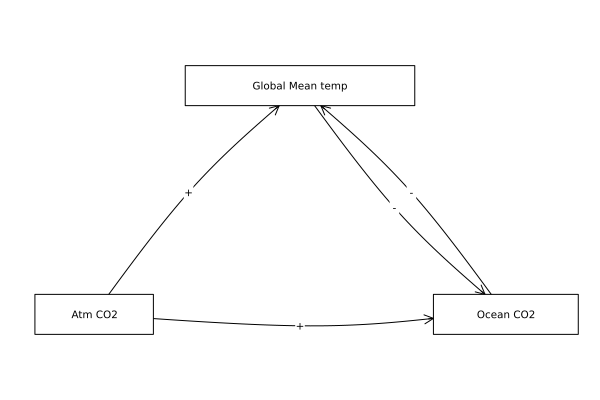

In [ ]:
A = [0 0 1 ;
    1 0 1 ;
    1 0 0 ]

names = ["Global Mean temp", "Atm CO2", "Ocean CO2"]
# modify this dictionary to add labels
edge_labels = Dict((2, 1) => "+", (1,3) => "-", (2,3) => "+", (3,1) => "-")
shapes=[:rect, :rect, :rect]
xpos = [0, -0.9, 0.9]
ypos = [1, 0, 0]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

From Henry's law, we know that as the partial pressure of CO2 increases above a body of water, the solubility of CO2 in the water increases. This led us to choose a "+" for the relationship between Atm CO2 and Ocean CO2: As atm CO2 increases, so will oceanic CO2. On the other hand, as surface temperature increases, the ability of CO2 to dissolve in water decreases. So as global mean temperature rises (along with ocean surface temperature), less CO2 will dissolve, resulting in a "-" relationship. Additionally for this inverse, or dampening, relationship, oceanic carbon is a carbon sink, with more dissolved carbon resulting in slower warming. This solidifies our selection of using "-". We also know from the greenhouse effect that as more CO2 resides in the atmosphere, more radiation will be trapped in the atmosphere contributing to a rise in temperature. Given this, we chose a "+" relationship. 

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

Our system is not in compliance. After traveling 15 km to the second inflow point, the concentration is around 3.5 kg/(1000m^3), which is above the regulatory limit. After mixing, it goes up even further. It is certainly not in compliance.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

There is 1 stable equilibrium at around -47 degrees. All points approach this value between -60 and 30 degrees, and after expanding the range, all ranges we tested all approach -47. This explains why we are not choosing -60 and 30 degrees as points of unstable equilibrium, since at these points on either side of them, the temperature will still approach -47.

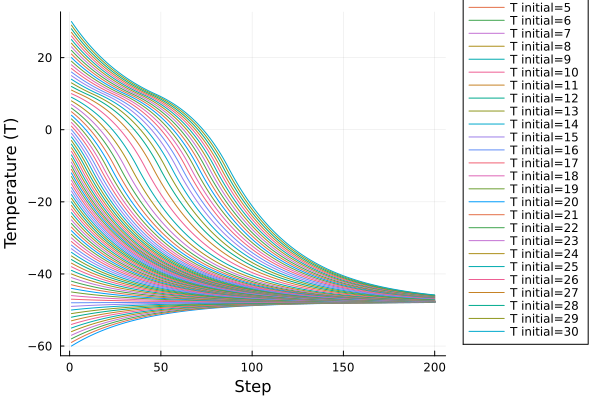

In [100]:
# 3.2
# initial conditions/defining variables

A = 221.2
B = -1.3
C = 51
S = 1272

# albedo
ai = 0.5
a0 = 0.3


p = plot(xlabel="Step", ylabel="Temperature (T)", lw=2, legend = :outerbottomright)
# loop through T-values
for T0 in -60:1:30
    Ti = T0
    T = []
    I = []
    # 200 years of 1-year timesteps
    for i = 1:200
        push!(I, i)
        push!(T, Ti)
        # albedo based on temperature
        if Ti <= -10
            a = ai
        elseif Ti >= 10
            a = a0
        else
            a = ai + ((a0-ai)*((Ti+10)/20))
        end
        # new temperature
        T_new = Ti + 1/C * (((1-a)*S/4) - A + B*Ti)
        Ti = T_new
        
    end
    plot!(I, T, label="T initial=$T0")
end
display(p)

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

Increasing the amount of solar radiation to S = 1368 creates another equilibrium point around 14 degrees C. This shows that an increase in solar radiation does lead to an increase in steady state temperature. It is possible that this increase in solar radiation could warm the planet to pre-industrial temperatures of 14 degrees C. 

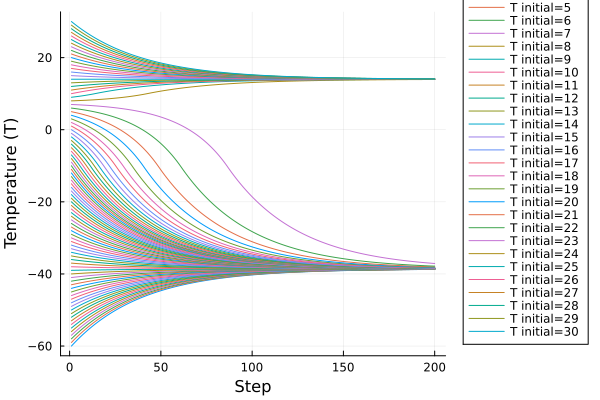

In [6]:
# 3.3
# initial conditions/defining variables

A = 221.2
B = -1.3
C = 51
S = 1368

# albedo
ai = 0.5
a0 = 0.3


p = plot(xlabel="Step", ylabel="Temperature (T)", lw=2, legend = :outerbottomright)
# loop through T-values
for T0 in -60:1:30
    Ti = T0
    T = []
    I = []
    # 200 years of 1-year timesteps
    for i = 1:200
        push!(I, i)
        push!(T, Ti)
        # albedo based on temperature
        if Ti <= -10
            a = ai
        elseif Ti >= 10
            a = a0
        else
            a = ai + ((a0-ai)*((Ti+10)/20))
        end
        # new temperature
        T_new = Ti + 1/C * (((1-a)*S/4) - A + B*Ti)
        Ti = T_new
        
    end
    plot!(I, T, label="T initial=$T0")
end
display(p)

## References

List any external references consulted, including classmates.